In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
gold_data = pd.read_csv('gld_price_data.csv')

In [3]:
# printing the first 5 rows of the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
# printing last 5 rows of the dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [5]:
# number of rows and columns in the dataset
gold_data.shape

(2290, 6)

In [6]:
# getting some basic information about the dataset
gold_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   str    
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), str(1)
memory usage: 107.5 KB


In [7]:
# checking the number of missing values in each column
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [8]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
  1. positive correlation
  2. negative correlation

In [9]:
correlation = gold_data.corr(numeric_only=True) # data contains a date column (like '1/2/2008') stored as a string. When you call .corr(), it tries to convert all columns to numeric values, but the date string can't be converted to a float.

<Axes: >

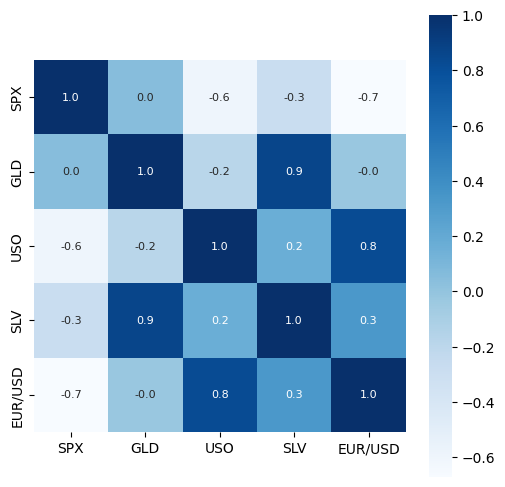

In [26]:
# constructing a heatmap to understand the correlation between the columns
plt.figure(figsize=(6, 6))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size': 8}, cmap='Blues')

In [11]:
# correlation values of GOLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<Axes: xlabel='GLD', ylabel='Count'>

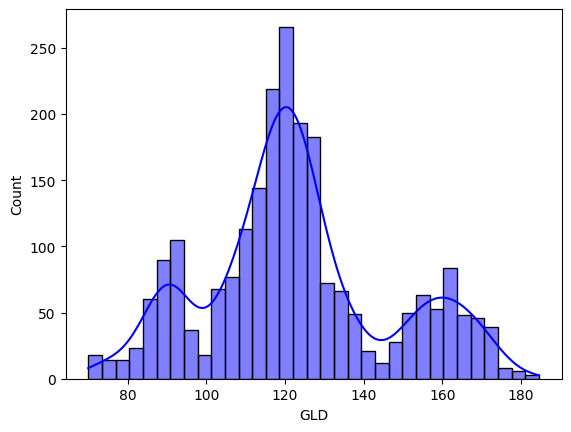

In [12]:
# checking the distribution of the gold price
sns.histplot(gold_data['GLD'], kde=True, color='blue')

*Splitting the Features and Target*

In [13]:
X = gold_data.drop(['Date', 'GLD'], axis=1)
Y = gold_data['GLD']

In [14]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [15]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


*Splitting into Training Data and Test Data*

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

*Model Training: Random Forest Regression*

In [17]:
regression = RandomForestRegressor(n_estimators=100)

In [18]:
# training the model
regression.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

*Model Evaluation*

In [19]:
# predicting the prices of gold on the test data
test_data_prediction = regression.predict(X_test)

In [20]:
print(test_data_prediction)

[168.75589977  82.18719995 115.8263001  127.70020052 120.86700133
 154.65669783 150.71009996 125.99690076 117.4774989  126.15839991
 116.60170129 171.99930098 141.19499824 167.91979841 115.14839996
 117.67760066 137.71070299 170.54970156 159.73820293 159.7702993
 155.16750039 125.27020039 175.96099925 157.18340333 125.26320074
  93.79589988  77.00880013 120.45579978 119.0034992  167.47599957
  88.20990043 125.0718002   91.04750037 117.71040001 121.16259916
 136.04730106 115.39290111 115.13310054 147.41099957 107.24350083
 104.44230236  87.18619792 126.48230062 117.97560004 153.85449844
 119.85129971 108.36470021 108.04429822  93.10250045 127.23749754
  75.46050014 113.6337994  121.32790032 111.36229893 118.80169884
 120.54849955 159.0078997  167.42790055 147.17559724  85.77349846
  94.27790053  86.866699    90.41540041 118.97800081 126.44330074
 127.49960006 170.95690026 122.33349936 117.48359897  98.11860019
 168.12320101 143.25519856 132.19780197 121.2186021  121.37709929
 119.845900

In [21]:
# R Squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print('R Squared Error : ', error_score)

R Squared Error :  0.9894198317540841


*Compare the Actual and Predicted Values in a Plot*

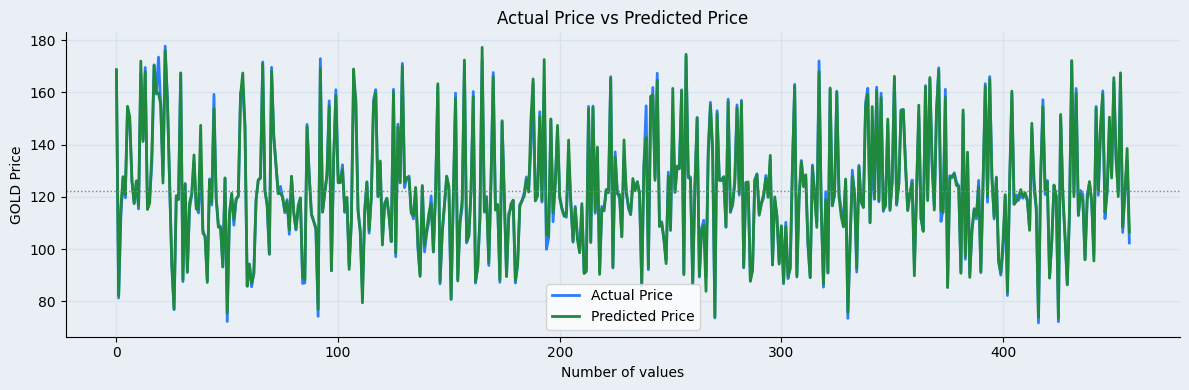

In [27]:
Y_test = list(Y_test)
plt.figure(figsize=(12, 4))
mean_val = np.mean(Y_test)
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor('#e9eff5')
ax.set_facecolor('#e9eff5')
plt.plot(Y_test, color='#2b7cff', linewidth=2, label='Actual Price')
plt.plot(test_data_prediction, color='#1f8a3d', linewidth=2, label='Predicted Price')
plt.axhline(mean_val, color='gray', linestyle=':', linewidth=1)
plt.grid(color='#d8e3f0', linestyle='-', linewidth=1)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GOLD Price')
plt.legend()
plt.tight_layout()
plt.show()

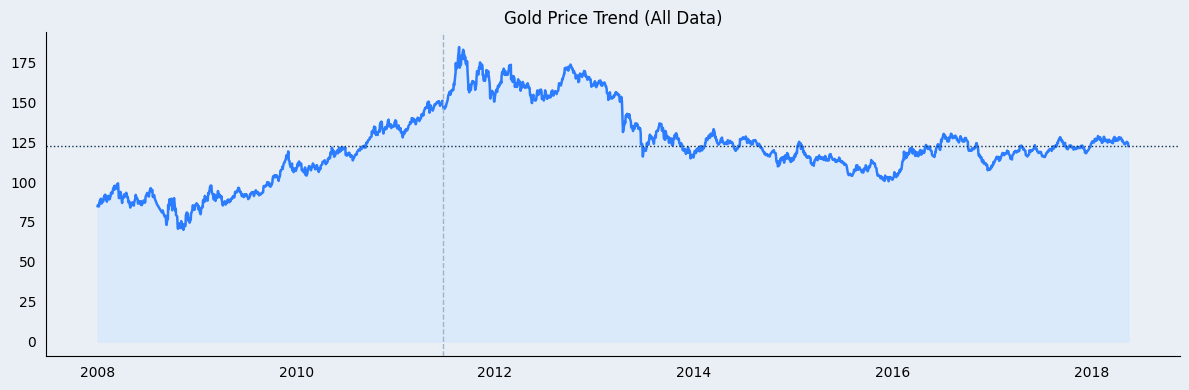

In [28]:
# Styled full time-series chart
gd = gold_data.copy()
if 'Date' in gd.columns:
    try:
        gd['Date'] = pd.to_datetime(gd['Date'])
        gd = gd.sort_values('Date')
        x = gd['Date']
    except Exception as e:
        x = range(len(gd))
else:
    x = range(len(gd))
y = gd['GLD']
plt.figure(figsize=(12, 4))
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor('#e9eff5')
ax.set_facecolor('#e9eff5')
plt.plot(x, y, color='#2b7cff', linewidth=1.8)
plt.fill_between(x, y, color='#cfe6ff', alpha=0.5)
mean_val = y.mean()
plt.axhline(mean_val, color='#0f314f', linestyle=':', linewidth=1)
if hasattr(x, 'iloc'):
    vline_x = x.iloc[len(x)//3]
else:
    vline_x = len(x)//3
plt.axvline(vline_x, color='#9fb4cc', linestyle='--', linewidth=1)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False, bottom=False)
plt.grid(False)
plt.title('Gold Price Trend (All Data)')
plt.tight_layout()
plt.show()